# Exposure Time Calculations for Constraining the presence of polarized speckles at the HLC Band-1 Focal Plane

In [1]:
# Package inputs
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import proper
import roman_preflight_proper
from corgisim import scene, instrument
from tqdm import tqdm
from pathlib import Path
from astropy.io import fits

In [132]:
# USER INPUTS
star_choice = "Beta Car" # must be in 'starlist'
single_texp = 60 # Seconds
cr_rate = 0 # Keeping zero for purposes of this simulation

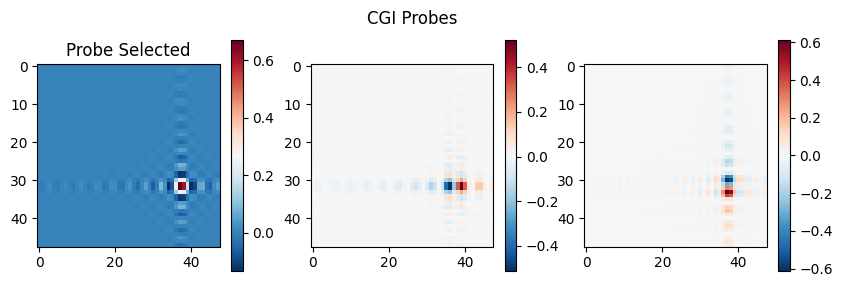

In [129]:
# Load the probe offices
PROBE_SELECT = 0
probepath = Path.home() / 'corgihowfsc/corgihowfsc/model/probes'
probe0file = probepath / 'nfov_dm_dmrel_4_1.0e-05_cos.fits'
probe1file = probepath / 'nfov_dm_dmrel_4_1.0e-05_sinlr.fits'
probe2file = probepath / 'nfov_dm_dmrel_4_1.0e-05_sinud.fits'

scale = np.sqrt(10)
probe0 = fits.getdata(probe0file) / scale
probe1 = fits.getdata(probe1file) / scale
probe2 = fits.getdata(probe2file) / scale
probes = [probe0, probe1, probe2]
probe = probes[PROBE_SELECT]

plt.figure(figsize=[10, 3])
plt.suptitle("CGI Probes")
for i, probe in enumerate([probe0, probe1, probe2]):
    plt.subplot(1, 3, i+1)
    if i == PROBE_SELECT:
        plt.title("Probe Selected")
    plt.imshow(probe, cmap="RdBu_r")
    plt.colorbar()
plt.show()

In [130]:
# Star dictionaries
starlist = ["Beta Car", "Beta Lib", "Beta TrA", "Gamma Peg"]
bet_car = {"name": r"$\Beta$"+" Carinae", "Vmag": 1.69, "Spectal Type":"A1III"}
bet_lib = {"name": r"$\Beta$"+" Librae", "Vmag": 2.62, "Spectal Type":"B8V"}
bet_tra = {"name": r"$\Beta$"+" Triangulae Australis", "Vmag": 2.85, "Spectal Type":"F1V"}
gam_peg = {"name": r"$\gamma$"+" Pegisae", "Vmag": 2.84, "Spectal Type":"B2IV"}

match star_choice:
    case "Beta Car":
        star_params = bet_car
    case "Beta Lib":
        star_params = bet_lib
    case "Beta TrA":
        star_params = bet_tra
    case "Gamma Peg":
        star_params = gam_peg
    case _:
        raise ValueError(f"star choice '{star_choice}' not in {starlist}")

## Generate the Polarized Scenes for both the 'POL0' and 'POL45' prisms

In [131]:
# Ensure we have the Proper model
roman_preflight_proper.copy_here()

# USER INPUTS
Vmag = star_params["Vmag"]
spectral_type = star_params["Spectal Type"]
cgi_mode = 'excam'
bandpass_corgisim = '1B'
cor_type = 'hlc'
output_dim = 51
rootname = 'hlc_ni_3e-8'
pixscale_mas = 21.8 # mas/pix

# Set up a mask at the IWA
pixscale_rad = pixscale_mas / 1e3 / 206265
pixscale_lamD = 2.4 / 575e-9 * pixscale_rad
array_center = output_dim // 2
mask = np.zeros([output_dim, output_dim])
rad = pixscale_lamD * output_dim / 2
x = np.linspace(-rad, rad, output_dim)
x, y = np.meshgrid(x, x)
r = np.hypot(y, x)
mask[r <= 5] = 1
mask[r <= 3] = 0

# Init scene
host_star_properties = {
    'Vmag': Vmag,
    'spectral_type': spectral_type,
    'magtype': 'vegamag'
}
base_scene = scene.Scene(host_star_properties, point_source_info=None)

# init dms
dm1 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm1_v.fits' )
dm2 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm2_v.fits' )

# Init instrument
optics_keywords = {
        'cor_type':cor_type,
        'use_errors':2,
        'polaxis':10,
        'output_dim':output_dim,
        'prism':'POL0',
        'use_dm1':1,
        'dm1_v':dm1 + probe,
        'use_dm2':1,
        'dm2_v':dm2,
        'use_fpm':1,
        'use_lyot_stop':1,
        'use_field_stop':1
}

# Remember to clear polarized scenes
polarized_scenes = []
for prism in ['POL0', 'POL45']:

    # Swap the wollaston prism
    optics_keywords['prism'] = prism
    print(f"Simulating PSF with prism  = {optics_keywords['prism']}") 
    
    # re-init optics and generate the PSF
    optics = instrument.CorgiOptics(cgi_mode, bandpass_corgisim, optics_keywords=optics_keywords, if_quiet=True)
    sim_scene = optics.get_host_star_psf(base_scene)
    polarized_scenes.append(sim_scene)

sim_scene_Q = polarized_scenes[0]
sim_scene_U = polarized_scenes[1]

Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.


In [ ]:
# # Generate image for contrast normalization

# # Init instrument
# optics_keywords = {
#         'cor_type':cor_type,
#         'use_errors':2,
#         'polaxis':10,
#         'output_dim':output_dim,
#         'prism':'POL0',
#         'use_dm1':1,
#         'dm1_v':dm1,
#         'use_dm2':1,
#         'dm2_v':dm2,
#         'use_fpm':0,
#         'use_lyot_stop':1,
#         'use_field_stop':0,
#         'use_pupil_mask':0
# }

# # Remember to clear polarized scenes
# _polarized_scenes = []
# for prism in ['POL0', 'POL45']:

#     # Swap the wollaston prism
#     optics_keywords['prism'] = prism
#     print(f"Simulating PSF with prism  = {optics_keywords['prism']}") 
    
#     # re-init optics and generate the PSF
#     _optics = instrument.CorgiOptics(cgi_mode, bandpass_corgisim, optics_keywords=optics_keywords, if_quiet=True)
#     _sim_scene = _optics.get_host_star_psf(base_scene)
#     _polarized_scenes.append(_sim_scene)

# _sim_scene_Q = _polarized_scenes[0]
# _sim_scene_U = _polarized_scenes[1]

# # get the max
# norm_I0 = _sim_scene_Q.host_star_image.data[0].max()
# norm_I90 = _sim_scene_Q.host_star_image.data[1].max()
# norm_I45 = _sim_scene_U.host_star_image.data[0].max()
# norm_I135 = _sim_scene_U.host_star_image.data[1].max()

# print(f"I0 = {norm_I0}")
# print(f"I0 = {norm_I90}")
# print(f"I0 = {norm_I45}")
# print(f"I0 = {norm_I135}")

In [ ]:
# plt.imshow(_sim_scene_Q.host_star_image.data[0])
# plt.colorbar()

In [ ]:
# # What is the level of polarization we expect
# norm = sim_scene_Q.host_star_image.data.max()
# plt.figure(figsize=[12, 3])
# plt.subplot(131)
# plt.title(r"$I_0$")
# plt.imshow(sim_scene_Q.host_star_image.data[0] / norm_I0)
# plt.colorbar()
# plt.subplot(132)
# plt.title(r"$I_{90}$")
# plt.imshow(sim_scene_Q.host_star_image.data[1] / norm_I135)
# plt.colorbar()
# plt.subplot(133)
# diff = (sim_scene_Q.host_star_image.data[0] - sim_scene_Q.host_star_image.data[1]) / norm
# plt.title(r"$Q$")
# plt.imshow(diff, cmap="RdBu_r")
# plt.colorbar()
# plt.show()

# Performing the Photon Counting Simulations

Running Experment for Different Coadds:   0%|                                      | 0/9 [00:00<?, ?it/s]/home/jarenashcraft/corgisim/corgisim/instrument.py:1187: UserWarning: Detector noise will be different for each sub frame in polarimetry mode. For accurate detector image with noise, please generate full frame image.
  warnings.warn('Detector noise will be different for each sub frame in polarimetry mode. For accurate detector image with noise, please generate full frame image.')
/tmp/ipykernel_86967/1416409996.py:79: RuntimeWarning: invalid value encountered in divide
  q_multiplier = (q_img / DoLP) ** 2
/tmp/ipykernel_86967/1416409996.py:80: RuntimeWarning: invalid value encountered in divide
  u_multiplier = (u_img / DoLP) ** 2
Running Experment for Different Coadds: 100%|██████████████████████████████| 9/9 [00:49<00:00,  5.49s/it]


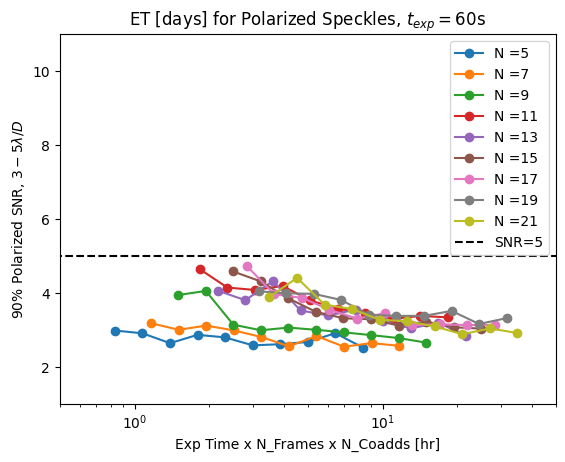

In [133]:
# gains = [799] #np.logspace(1, 3, 10)
n_frames = np.logspace(np.log10(5), np.log10(50), 10)
s_to_hr = 1 / 3600
coadds = np.arange(5, 22, 2)

# mostly for debugging
plot_intermediates = False

plt.figure()
plt.title("ET [days] for Polarized Speckles, "+r"$t_{exp}=$"+f"{single_texp}s")
for N_COADDS in tqdm(coadds, desc="Running Experment for Different Coadds"):

    mean_Qs = []
    mean_Us = []
    mean_DoLPs = []

    
    # Re-initialize detector
    emccd_keywords ={'em_gain':gains[0],
                     'cr_rate':cr_rate}
    detector = instrument.CorgiDetector(emccd_keywords,
                                        photon_counting=False)
    
    for i, N_FRAMES in enumerate(n_frames):

        N_FRAMES = int(N_FRAMES)
        
        I0s = []
        I90s = []
        I45s = []
        I135s = []
        
        for j in range(N_FRAMES):
            I0 = 0
            I90 = 0
            I45 = 0
            I135 = 0
    
            for _ in range(N_COADDS):
                
                # Re-sample scene from flux map
                sim_scene = detector.generate_detector_image(sim_scene_Q, single_texp)
                I0 += sim_scene.image_on_detector.data[0]
                I90 += sim_scene.image_on_detector.data[1]
                
                # Re-sample scene from flux map
                sim_scene = detector.generate_detector_image(sim_scene_U, single_texp)
                I45 += sim_scene.image_on_detector.data[0]
                I135 += sim_scene.image_on_detector.data[1]
    
            I0s.append(I0)
            I90s.append(I90)
            I45s.append(I45)
            I135s.append(I135)

        # Get mean and variance
        I0 = np.nanmedian(I0s, axis=0)
        I90 = np.nanmedian(I90s, axis=0)
        I45 = np.nanmedian(I45s, axis=0)
        I135 = np.nanmedian(I135s, axis=0)

        var_I0 = np.nanvar(I0s, axis=0)
        var_I90 = np.nanvar(I90s, axis=0)
        var_I45 = np.nanvar(I45s, axis=0)
        var_I135 = np.nanvar(I135s, axis=0)
        
        q_img = I0 - I90
        u_img = I45 - I135
        i_img = I0 + I90
    
        # Propagate uncertainty
        var_q = var_I0 + var_I90
        var_u = var_I45 + var_I135
        
        # Compute polarized intensity
        DoLP = np.sqrt(q_img**2 + u_img**2)
        
        # Propagate Uncertainty
        q_multiplier = (q_img / DoLP) ** 2
        u_multiplier = (u_img / DoLP) ** 2
        var_DoLP = q_multiplier * var_q + u_multiplier * var_u
        DoLP /= np.sqrt(var_DoLP)

        # Find max signal in near-IWA annulus
        mean_dolp = np.nanpercentile(DoLP[mask==1], 90)

        # Append to the DoLPs list for plotting
        mean_DoLPs.append(mean_dolp)
    
        if plot_intermediates:

            # Regenerate the working angle patches for plotting
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            im1 = axes[0].imshow(I0, origin='lower')
            axes[0].set_title(f'0 deg image with noise, hlc \n t = {single_texp * s_to_day}d')
            axes[0].add_patch(IWA)
            axes[0].add_patch(OWA)
            fig.colorbar(im1, ax=axes[0], shrink=0.7)
    
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
            
            im2 = axes[1].imshow(I90, origin='lower')
            axes[1].set_title(f'90 deg image with noise, hlc \n t = {single_texp * s_to_day}d')
            axes[1].add_patch(IWA)
            axes[1].add_patch(OWA)
            fig.colorbar(im2, ax=axes[1], shrink=0.7)

        
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
            
            im3 = axes[2].imshow(DoLP, origin='lower', cmap="Spectral", vmin=1, vmax=9)
            axes[2].set_title('DoLP image, hlc')
            axes[2].add_patch(IWA)
            axes[2].add_patch(OWA)
            fig.colorbar(im3, ax=axes[2], shrink=0.7, label="SNR")
            
            plt.tight_layout()
            plt.show()


    # Begin plotting standard deviation of polarized intensity in annulus
    # Multiply by 2 to account for separate Q and U exposures
    plt.plot(n_frames * s_to_hr * 2 * single_texp * N_COADDS, mean_DoLPs, marker="o", label=f"N ={N_COADDS}")

plt.xscale("log")
plt.xlabel("Exp Time x N_Frames x N_Coadds [hr]")
plt.ylabel(r"$90\%$"+" Polarized SNR, "+r"$3-5\lambda/D$")
plt.hlines(5, 1e-1, 5e2, color="k", linestyle="dashed", label="SNR=5")
plt.xlim(5e-1, 5e1)
plt.ylim(1, 11)
plt.legend()
plt.show()

In [109]:
s_to_day = 1.15741e-5
gain = 713
N_COADDS = 5 #n_frames[3]
single_texp = 120
N_FRAMES = n_frames[2]

# mostly for debugging

emccd_keywords ={'em_gain':gain,
                 'cr_rate':cr_rate}
detector = instrument.CorgiDetector(emccd_keywords,
                                    photon_counting=False)

N_FRAMES = int(N_FRAMES)

I0s = []
I90s = []
I45s = []
I135s = []

for x in range(N_FRAMES):
    
    I0 = 0.
    I90 = 0.
    I45 = 0.
    I135 = 0.

    for _ in range(N_COADDS):
        
        # Re-sample scene from flux map
        sim_scene = detector.generate_detector_image(sim_scene_Q, single_texp)
        I0 += sim_scene.image_on_detector.data[0].astype(float)
        I90 += sim_scene.image_on_detector.data[1].astype(float)
        
        # Re-sample scene from flux map
        sim_scene = detector.generate_detector_image(sim_scene_U, single_texp)
        I45 += sim_scene.image_on_detector.data[0].astype(float)
        I135 += sim_scene.image_on_detector.data[1].astype(float)
    
    I0s.append(I0)
    I90s.append(I90)
    I45s.append(I45)
    I135s.append(I135)

# Get mean and variance
I0 = np.nanmean(I0s, axis=0)
I90 = np.nanmean(I90s, axis=0)
I45 = np.nanmean(I45s, axis=0)
I135 = np.nanmean(I135s, axis=0)

var_I0 = np.nanvar(I0s, axis=0)
var_I90 = np.nanvar(I90s, axis=0)
var_I45 = np.nanvar(I45s, axis=0)
var_I135 = np.nanvar(I135s, axis=0)

q_img = I0 - I90
u_img = I45 - I135
i_img = I0 + I90

# Propagate uncertainty
var_q = var_I0 + var_I90
var_u = var_I45 + var_I135

# Compute polarized intensity
DoLP = np.sqrt(q_img**2 + u_img**2)

# Propagate Uncertainty
q_multiplier = (q_img / DoLP) ** 2
u_multiplier = (u_img / DoLP) ** 2
var_DoLP = q_multiplier * var_q + u_multiplier * var_u
DoLP /= np.sqrt(var_DoLP)

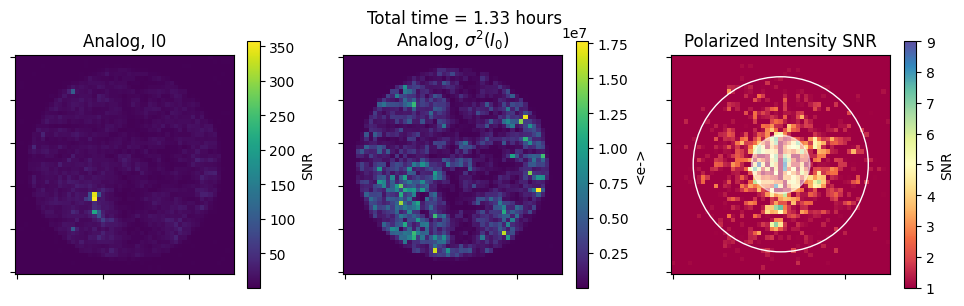

In [110]:
plt.figure(figsize=[12, 3.2])
plt.suptitle(f"Total time = {(N_COADDS * N_FRAMES * single_texp)/60/60:.2f} hours")
plt.subplot(131)
plt.title("Analog, I0")
plt.imshow(I0 / np.sqrt(var_I0), cmap="viridis")
plt.colorbar(label="SNR")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(132)
plt.title("Analog, "+r"$\sigma^2 (I_{0})$")
plt.imshow(var_I0, cmap="viridis")
plt.colorbar(label="<e->")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(133)
plt.title("Polarized Intensity SNR")
plt.imshow(DoLP, cmap="Spectral", vmax=9, vmin=1)
plt.colorbar(label="SNR")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
ax = plt.gca()
ax.add_patch(IWA)
ax.add_patch(OWA)
plt.show()